Generating SI Movie S1 (60 frames, p_l sweep 0.1-0.5)...
Saved: SI_Movie_S1.gif (1.53 MB)


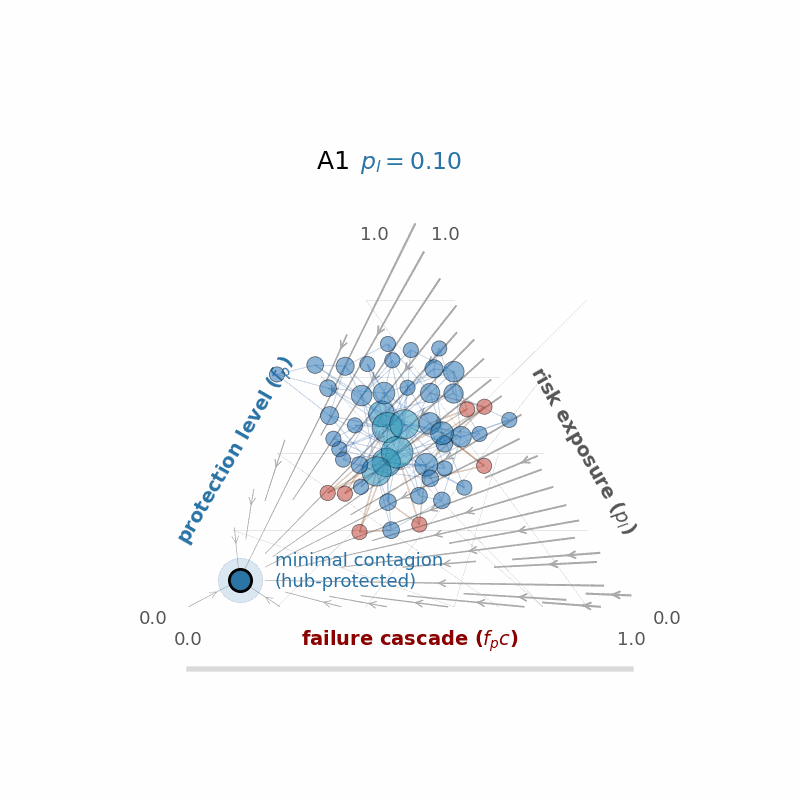

In [1]:
"""
SI Movie S1: Failure Propagation Attractor Evolution (Fig 3A style)
===================================================================
p_l sweep from 0.1 to 0.5 at fixed gamma=0.3.
No trail line. Large attractor circle. Vivid streamplot arrows.
Matches manuscript Figure 3 Panel A visual style.
Output: SI_Movie_S1.gif (pillow writer, Windows compatible)
"""

import networkx as nx
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.colors
import math
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

###############################################################################
# Network
###############################################################################
G_ba = nx.barabasi_albert_graph(50, 3, seed=42)
pos_ba = nx.spring_layout(G_ba, seed=42, k=0.3)
N_nodes = G_ba.number_of_nodes()
deg_dict = dict(G_ba.degree())
deg_arr = np.array([deg_dict[i] for i in range(N_nodes)])
sorted_asc = np.argsort(deg_arr)
sorted_desc = np.argsort(-deg_arr)

###############################################################################
# Keyframes (matching Fig 3A p_l sweep)
###############################################################################
ATTRACTOR_KEYS = {
    0.1: (0.85, 0.08, 0.07),   # A1: protection-dominated
    0.2: (0.62, 0.25, 0.13),   # A2: mostly protected
    0.3: (0.38, 0.38, 0.24),   # A3: balanced
    0.4: (0.18, 0.60, 0.22),   # A4: failure-leaning
    0.5: (0.06, 0.82, 0.12),   # A5: failure-dominated
}
COLORS_KEYS = {
    0.1: '#2874A6', 0.2: '#229954', 0.3: '#D68910',
    0.4: '#E67E22', 0.5: '#C0392B',
}
PANEL_LABELS = {0.1:'A1', 0.2:'A2', 0.3:'A3', 0.4:'A4', 0.5:'A5'}

for k in ATTRACTOR_KEYS:
    p,f,o = ATTRACTOR_KEYS[k]; s=p+f+o; ATTRACTOR_KEYS[k]=(p/s,f/s,o/s)

def to_2d(p, f, o):
    return (f + 0.5*o, (math.sqrt(3)/2.0)*o)

def from_2d_to_bary(x2d, y2d):
    z=(2.0/math.sqrt(3))*y2d; y=x2d-0.5*z; x=1.0-(y+z)
    return (x, y, z)

def compute_flow(h, l, n, ht, lt, nt, steps=5):
    for _ in range(steps):
        dist=math.sqrt((h-ht)**2+(l-lt)**2+(n-nt)**2)
        sc=0.30+0.20*min(dist*2,1.0)
        h+=sc*(ht-h); l+=sc*(lt-l); n+=sc*(nt-n)
        h=max(0,h); l=max(0,l); n=max(0,n)
        s=h+l+n
        if s<1e-12: break
        h/=s; l/=s; n/=s
    return h, l, n

N_FRAMES = 60
pl_frames = np.linspace(0.1, 0.5, N_FRAMES)

def interp_attractor(pl_val):
    keys=sorted(ATTRACTOR_KEYS.keys())
    if pl_val<=keys[0]: return ATTRACTOR_KEYS[keys[0]]
    if pl_val>=keys[-1]: return ATTRACTOR_KEYS[keys[-1]]
    for i in range(len(keys)-1):
        if keys[i]<=pl_val<=keys[i+1]:
            t=(pl_val-keys[i])/(keys[i+1]-keys[i])
            a0=ATTRACTOR_KEYS[keys[i]]; a1=ATTRACTOR_KEYS[keys[i+1]]
            p=a0[0]+t*(a1[0]-a0[0]); f=a0[1]+t*(a1[1]-a0[1]); o=a0[2]+t*(a1[2]-a0[2])
            s=p+f+o; return (p/s,f/s,o/s)

def interp_color(pl_val):
    keys=sorted(COLORS_KEYS.keys())
    if pl_val<=keys[0]: return COLORS_KEYS[keys[0]]
    if pl_val>=keys[-1]: return COLORS_KEYS[keys[-1]]
    for i in range(len(keys)-1):
        if keys[i]<=pl_val<=keys[i+1]:
            t=(pl_val-keys[i])/(keys[i+1]-keys[i])
            c0=matplotlib.colors.to_rgb(COLORS_KEYS[keys[i]])
            c1=matplotlib.colors.to_rgb(COLORS_KEYS[keys[i+1]])
            return tuple(c0[j]+t*(c1[j]-c0[j]) for j in range(3))

def get_panel_label(pl_val):
    keys=sorted(PANEL_LABELS.keys())
    closest = min(keys, key=lambda k: abs(k-pl_val))
    if abs(closest-pl_val) < 0.03:
        return PANEL_LABELS[closest]
    return None

###############################################################################
# Streamplot grid
###############################################################################
nx_grid, ny_grid = 30, 30
x2d_vals = np.linspace(0, 1, nx_grid)
y2d_vals = np.linspace(0, math.sqrt(3)/2, ny_grid)
X2d = np.zeros((ny_grid, nx_grid)); Y2d = np.zeros((ny_grid, nx_grid))
for i, y2d in enumerate(y2d_vals):
    for j, x2d in enumerate(x2d_vals):
        X2d[i,j] = x2d; Y2d[i,j] = y2d

v_left=np.array([0,0]); v_right=np.array([1,0]); v_top=np.array([0.5,math.sqrt(3)/2])

###############################################################################
# Drawing
###############################################################################
def draw_gridlines(ax):
    for frac in [0.2, 0.4, 0.6, 0.8]:
        x0=0.5*frac; y0=(math.sqrt(3)/2)*frac; x1=1.0-0.5*frac
        ax.plot([x0,x1],[y0,y0],color='gray',alpha=0.25,lw=0.6,zorder=1)
        bx=frac; tx=0.5+0.5*(1-frac); ty=(math.sqrt(3)/2)*(1-frac)
        ax.plot([bx,tx],[0,ty],color='gray',alpha=0.25,lw=0.6,zorder=1)
        ax.plot([frac*0.5,frac+(1-frac)*0.5],[frac*math.sqrt(3)/2,0],color='gray',alpha=0.25,lw=0.6,zorder=1)

def draw_labels(ax):
    lfs=14
    mid_bot=(v_left+v_right)/2
    ax.text(mid_bot[0],mid_bot[1]-0.05,'failure cascade ($f_p c$)',fontsize=lfs,ha='center',va='top',color='#8B0000',fontweight='bold')
    mid_left=(v_left+v_top)/2; off=0.16
    ax.text(mid_left[0]-off*math.cos(math.radians(30)),mid_left[1]-off*math.sin(math.radians(30)),'protection level ($f_p$)',fontsize=lfs,ha='center',va='center',color='#2874A6',fontweight='bold',rotation=60)
    mid_right=(v_right+v_top)/2
    ax.text(mid_right[0]+off*math.cos(math.radians(30)),mid_right[1]-off*math.sin(math.radians(30)),'risk exposure ($p_l$)',fontsize=lfs,ha='center',va='center',color='#555555',fontweight='bold',rotation=-60)
    tfs=13; tick_off=0.055
    for val in [0.0,1.0]:
        tx=v_left[0]+val*(v_right[0]-v_left[0])
        ax.text(tx,-tick_off,f'{val:.1f}',fontsize=tfs,ha='center',va='top',color='#555')
    for val in [0.0,1.0]:
        pt=v_left+val*(v_top-v_left); dx=-tick_off*math.cos(math.radians(30)); dy=-tick_off*math.sin(math.radians(30))
        ax.text(pt[0]+dx,pt[1]+dy,f'{val:.1f}',fontsize=tfs,ha='right',va='center',color='#555')
    for val in [0.0,1.0]:
        pt=v_right+val*(v_top-v_right); dx=tick_off*math.cos(math.radians(30)); dy=-tick_off*math.sin(math.radians(30))
        ax.text(pt[0]+dx,pt[1]+dy,f'{val:.1f}',fontsize=tfs,ha='left',va='center',color='#555')

def draw_network(inset_ax, pl_val):
    inset_ax.clear(); inset_ax.axis('off'); inset_ax.patch.set_alpha(0.0)
    inset_ax.set_xlim(-1.3,1.3); inset_ax.set_ylim(-1.3,1.3)

    fail_frac = 0.05 + 1.50 * pl_val**1.2
    fail_frac = min(fail_frac, 0.92)
    n_fail = int(round(fail_frac * N_nodes))

    if pl_val <= 0.2:
        fail_nodes = set(sorted_asc[:n_fail])
    elif pl_val <= 0.3:
        np.random.seed(42)
        fail_nodes = set(np.random.choice(N_nodes, n_fail, replace=False))
    else:
        fail_nodes = set(sorted_desc[:n_fail])

    node_colors=[]
    for i in range(N_nodes):
        if i in fail_nodes: node_colors.append('#C0392B')
        else:
            intensity=0.3+0.5*min(deg_arr[i]/max(deg_arr),1.0)
            node_colors.append((0.1,0.2+0.5*intensity,0.7))
    node_sizes=[45+25*deg_dict[i] for i in range(N_nodes)]
    edge_colors=[]; edge_widths=[]
    for u,v in G_ba.edges():
        if u in fail_nodes and v in fail_nodes: edge_colors.append((0.8,0.15,0.15,0.45)); edge_widths.append(2.5)
        elif u in fail_nodes or v in fail_nodes: edge_colors.append((0.6,0.35,0.15,0.30)); edge_widths.append(1.2)
        else: edge_colors.append((0.15,0.35,0.7,0.25)); edge_widths.append(0.8)
    nx.draw_networkx_edges(G_ba,pos_ba,width=edge_widths,edge_color=edge_colors,ax=inset_ax)
    nx.draw_networkx_nodes(G_ba,pos_ba,node_size=node_sizes,node_color=node_colors,edgecolors='black',linewidths=0.6,alpha=0.5,ax=inset_ax)

###############################################################################
# Figure + Animation
###############################################################################
fig = plt.figure(figsize=(8, 8), dpi=100)
ax = fig.add_subplot(111)
inset_ax = fig.add_axes([0.30, 0.26, 0.40, 0.40])

def animate(fi):
    ax.clear()
    ax.set_aspect('equal','box')
    ax.set_xlim(-0.20,1.20); ax.set_ylim(-0.18,math.sqrt(3)/2+0.23)
    ax.axis('off')

    draw_gridlines(ax)
    draw_labels(ax)

    pl_val = pl_frames[fi]
    ht,lt,nt = interp_attractor(pl_val)
    sc = interp_color(pl_val)

    # Streamplot (vivid, matching Fig 3A gray arrows)
    U=np.zeros((ny_grid,nx_grid)); V=np.zeros((ny_grid,nx_grid))
    for i,y2d in enumerate(y2d_vals):
        for j,x2d in enumerate(x2d_vals):
            h,l,nv=from_2d_to_bary(x2d,y2d)
            if h<-0.02 or l<-0.02 or nv<-0.02: U[i,j]=np.nan; V[i,j]=np.nan; continue
            h=max(0,h); l=max(0,l); nv=max(0,nv)
            ss=h+l+nv
            if ss<1e-12: U[i,j]=np.nan; V[i,j]=np.nan; continue
            h/=ss; l/=ss; nv/=ss
            h2,l2,n2=compute_flow(h,l,nv,ht,lt,nt)
            xo,yo=to_2d(h,l,nv); xn,yn=to_2d(h2,l2,n2)
            U[i,j]=xn-xo; V[i,j]=yn-yo

    flow_mag=np.sqrt(U**2+V**2); max_mag=np.nanmax(flow_mag)
    if max_mag and not np.isnan(max_mag):
        linewidth=0.8+2.5*(flow_mag/max_mag)
    else: linewidth=1.0

    ax.streamplot(X2d, Y2d, U, V, color='#AAAAAA', density=1.0,
                  linewidth=linewidth*0.5, arrowsize=1.2,
                  arrowstyle='->', zorder=3)

    # Attractor (large, no trail)
    ax_att,ay_att=to_2d(ht,lt,nt)
    ax.plot(ax_att,ay_att,'o',color=sc,markersize=32,alpha=0.15,zorder=14)
    ax.plot(ax_att,ay_att,'o',color=sc,markersize=16,markeredgecolor='black',markeredgewidth=2.0,zorder=15)

    # Panel label + p_l value
    pl_label = get_panel_label(pl_val)
    label_text = f'{pl_label}  ' if pl_label else ''
    ax.text(0.35,0.95,label_text,transform=ax.transAxes,fontsize=18,va='top',ha='left',color='black')
    ax.text(0.42,0.95,r'$p_l = '+f'{pl_val:.2f}'+r'$',transform=ax.transAxes,fontsize=17,color=sc,ha='left',va='top')

    # Equilibrium annotations
    if pl_val < 0.12:
        ax.text(ax_att+0.08,ay_att+0.02,'minimal contagion\n(hub-protected)',fontsize=13,color=sc,va='center')
    elif pl_val > 0.48:
        ax.text(ax_att-0.08,ay_att+0.02,'cascading failure\n(hub-vulnerable)',fontsize=13,color=sc,ha='right',va='center')

    # Progress bar
    progress = fi / (N_FRAMES - 1)
    ax.plot([0.0, 1.0], [-0.14, -0.14], '-', color='#DDD', linewidth=4, zorder=1)
    ax.plot([0.0, progress], [-0.14, -0.14], '-', color=sc, linewidth=4, zorder=2)

    # Network
    draw_network(inset_ax, pl_val)

print(f"Generating SI Movie S1 ({N_FRAMES} frames, p_l sweep 0.1-0.5)...")
ani = animation.FuncAnimation(fig, animate, frames=N_FRAMES, interval=500, blit=False)
ani.save('SI_Movie_S1.gif', writer='pillow', fps=4, dpi=100)
plt.close(fig)

fsize = os.path.getsize('SI_Movie_S1.gif')
print(f"Saved: SI_Movie_S1.gif ({fsize/1024/1024:.2f} MB)")

try:
    from IPython.display import Image, display
    display(Image(filename='SI_Movie_S1.gif'))
except: pass

Generating SI Movie S2 (190 frames at 4fps = 48s)...



KeyboardInterrupt

